In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np

## 全年

In [ ]:
df_merged = pd.read_csv(r"D:\Coding\Data\Lanzhou_chemical\Corr(INP_vs_element).csv")
print(df_merged.shape)

In [ ]:
df_merged.columns

In [ ]:
# ==========================================
# 1. 配置参数
# ==========================================
# 确保 df_merged 是已经对齐好时间的数据
# 确保 'T_a(degC)' 是数字类型

# 你感兴趣的所有物质列表
ELEMENT_LIST = [
    'OC(thermal)','EC(thermal)', 'OC(optical)', 'EC(optical)', 'Ca2+', 
    'Mg2+', 'K+', 'NH4+', 'Na+', 'SO42-', 
    'NO3-', 'Cl-', 'NH3', 'HNO3', 'SO2', 
    'HNO2', 'HCl', 'Pb', 'Se', 'Hg', 
    'Cr', 'Cd', 'Zn', 'Cu', 'Ni', 
    'Fe', 'Mn', 'Ti', 'Sb', 'Sn', 
    'V', 'Ba', 'As', 'Ca', 'K', 
    'Co', 'Mo', 'Ag', 'Sc', 'Tl',
    'Pd', 'Br', 'Te', 'Ga', 'Cs', 
    'Si', 'Au', 'Al', 'Nb', 'PM2.5'
]

# 你感兴趣的激活温度列表 (根据你的数据调整)
TEMPERATURE_LIST = [-35, -30, -25, -20, -15]

# INP 浓度列名
INP_COL = 'N_INP(#/L)'

# 是否取对数 (1:是, 0:否)
LOG_TAG = 1

# ==========================================
# 2. 定义计算函数
# ==========================================
def calculate_corr_cell(df, temp, element, log_tag):
    """
    计算特定温度下，INP与特定物质的相关系数
    返回格式化的字符串 (例如: "0.38*" 或 "0.12")
    """
    # 1. 筛选特定温度的数据
    df_temp = df[df['T_a(degC)'] == temp]
    
    # 2. 去除空值 (Pairwise deletion)
    df_sub = df_temp.dropna(subset=[element, INP_COL])
    
    # 3. 样本量检查 (如果样本太少，无法计算)
    if len(df_sub) < 3:
        return "nan"
    
    # 4. 提取数据
    x = df_sub[element]
    y = df_sub[INP_COL]
    
    # 5. 对数转换逻辑
    if log_tag:
        # 对数转换前必须确保数据 > 0
        valid_idx = (x > 0) & (y > 0)
        x = np.log10(x[valid_idx])
        y = np.log10(y[valid_idx])
        if len(x) < 3: return "nan"

    # 6. 计算 Pearson r 和 p
    # 如果数据方差为0（所有值都一样），pearsonr会报警告或返回nan，这里用try-except捕获
    #try:
    #    r, p = stats.pearsonr(x, y)
    #except Exception:
    #    return "nan"

    r, p = stats.pearsonr(x, y)

    # 7. 格式化输出
    if pd.isna(r):
        return "nan"
    
    # 标记显著性 (* 代表 p < 0.05)
    star = "*" if p < 0.05 else ""

    star = "**" if p < 0.01 else star
    
    return f"{r:.2f}{star}"

# ==========================================
# 3. 批量计算
# ==========================================
results = {}

print("开始批量计算相关系数...")

for temp in TEMPERATURE_LIST:
    row_name = f"INP{temp}" # 生成行名，如 INP-35
    row_data = {}
    
    for element in ELEMENT_LIST:
        # 检查元素列是否存在于数据中
        if element not in df_merged.columns:
            row_data[element] = "No Data"
            continue
            
        # 调用函数计算
        res_str = calculate_corr_cell(df_merged, temp, element, LOG_TAG)
        row_data[element] = res_str
    
    results[row_name] = row_data

# ==========================================
# 4. 生成表格并保存
# ==========================================
# 转换为 DataFrame (行是温度，列是物质名称)
df_result = pd.DataFrame(results).T 

# 打印预览
print("-" * 50)
print("Pearson 相关系数表 (带显著性标记 *)")
print("-" * 50)
print(df_result)

# 保存到 Excel
output_filename = 'Pearson_Correlation_Table.xlsx'
df_result.to_excel(output_filename)
print(f"\n结果已保存至: {output_filename}")


## 不同季节

In [ ]:
# 计算不同季节的相关系数

# ==========================================
# 1. 配置参数
# ==========================================
# 确保 df_merged 是已经对齐好时间的数据
# 确保 'T_a(degC)' 是数字类型

# 你感兴趣的所有物质列表
ELEMENT_LIST = [
    'OC(thermal)','EC(thermal)', 'OC(optical)', 'EC(optical)', 'Ca2+', 
    'Mg2+', 'K+', 'NH4+', 'Na+', 'SO42-', 
    'NO3-', 'Cl-', 'NH3', 'HNO3', 'SO2', 
    'HNO2', 'HCl', 'Pb', 'Se', 'Hg', 
    'Cr', 'Cd', 'Zn', 'Cu', 'Ni', 
    'Fe', 'Mn', 'Ti', 'Sb', 'Sn', 
    'V', 'Ba', 'As', 'Ca', 'K', 
    'Co', 'Mo', 'Ag', 'Sc', 'Tl',
    'Pd', 'Br', 'Te', 'Ga', 'Cs', 
    'Si', 'Au', 'Al', 'Nb', 'PM2.5'
]

# 你感兴趣的激活温度列表 (根据你的数据调整)
TEMPERATURE_LIST = [-35, -30, -25, -20, -15]

# INP 浓度列名
INP_COL = 'N_INP(#/L)'

# 是否取对数 (1:是, 0:否)
LOG_TAG = 1

# ==========================================
# 2. 定义计算函数
# ==========================================
def calculate_corr_cell(df, temp, element, log_tag):
    """
    计算特定温度下，INP与特定物质的相关系数
    返回格式化的字符串 (例如: "0.38*" 或 "0.12")
    """
    # 1. 筛选特定温度的数据
    df_temp = df[df['T_a(degC)'] == temp]
    
    # 2. 去除空值 (Pairwise deletion)

    # 确保每列均为数值类型
    df_temp.loc[:, element] = pd.to_numeric(df_temp.loc[:, element], errors='coerce')
    df_temp.loc[:, INP_COL] = pd.to_numeric(df_temp.loc[:, INP_COL], errors='coerce')

    df_temp = df_temp.replace(-999, np.nan)
    df_sub = df_temp.dropna(subset=[element, INP_COL])

    # 3. 样本量检查 (如果样本太少，无法计算)
    if len(df_sub) < 3:
        return "nan"
    
    # 4. 提取数据
    x = df_sub[element]
    y = df_sub[INP_COL]
    
    # 5. 对数转换逻辑
    if log_tag:
        # 对数转换前必须确保数据 > 0
        valid_idx = (x > 0) & (y > 0)
        x = np.log10(x[valid_idx])
        y = np.log10(y[valid_idx])
        if len(x) < 3: return "nan"

    # 6. 计算 Pearson r 和 p
    # 如果数据方差为0（所有值都一样），返回nan
    if len(set(x)) == 1 or len(set(y)) == 1:
        return "nan"
    
    r, p = stats.pearsonr(x, y)

    # 7. 格式化输出
    if pd.isna(r):
        return "nan"
    
    # 标记显著性 (* 代表 p < 0.05)
    star = "*" if p < 0.05 else ""

    star = "**" if p < 0.01 else star
    
    return f"{r:.2f}{star}"

# ==========================================
# 3. 批量计算
# ==========================================
for season in ['Spring', 'Summer', 'Autumn', 'Winter']:
    df_season = df_merged[df_merged['Season'] == season]
    results = {}

    print("开始批量计算相关系数...")

    for temp in TEMPERATURE_LIST:
        row_name = f"INP{temp}" # 生成行名，如 INP-35
        row_data = {}
        
        for element in ELEMENT_LIST:
            # 检查元素列是否存在于数据中
            if element not in df_season.columns:
                row_data[element] = "No Data"
                continue
                
            # 调用函数计算
            res_str = calculate_corr_cell(df_season, temp, element, LOG_TAG)
            row_data[element] = res_str
        
        results[row_name] = row_data

    # ==========================================
    # 4. 生成表格并保存
    # ==========================================
    # 转换为 DataFrame (行是温度，列是物质名称)
    df_result = pd.DataFrame(results).T 

    # 打印预览
    #print("-" * 50)
    #print("Pearson 相关系数表 (带显著性标记 *)")
    #print("-" * 50)
    #print(df_result)

    # 保存到 Excel
    output_filename = f'{season}_Pearson_Correlation_Table.xlsx'
    df_result.to_excel(output_filename)
    print(f"\n结果已保存至: {output_filename}")


## 特定温度

In [2]:
import pandas as pd
import scipy.stats as stats
import numpy as np

df_merged = pd.read_csv(r"D:\Coding\Data\Lanzhou_chemical\Corr_heatmap.csv")
df_merged['SNA'] = df_merged['NH4+'] + df_merged['SO42-'] + df_merged['NO3-']
df_merged['FMD'] = 2.20 * df_merged['Al'] + 2.49 * df_merged['Si'] + 1.63 * df_merged['Ca'] + 2.42 * df_merged['Fe'] + 1.94 * df_merged['Ti']

TARGET_TEMP = -30

ELEMENT_LIST = [
    "OC(optical)",
    "EC(optical)",
    "Ba",
    "Cu",
    "Zn",
    "Ca",
    "K",
    "Si",
    "Mn",
    "Fe",
    "Cl-",
    "NH4+",
    "SO42-",
    "NO3-",
    "N_10-500nm",
    "N_10-1000nm",
    "N_500-2500nm",
    "N_1000-2500nm",
    "SNA",
    "FMD",
]

INP_COL = "N_INP(#/L)"

LOG_TAG = 1


def calculate_corr_cell(df, temp, element, log_tag):
    """
    计算特定温度下，INP与特定物质的相关系数
    返回格式化的字符串 (例如: "0.38*" 或 "0.12")
    """
    # 1. 筛选特定温度的数据
    df_temp = df[df['T_a(degC)'] == temp]
    
    # 2. 去除空值 (Pairwise deletion)
    # 确保每列均为数值类型
    df_temp.loc[:, element] = pd.to_numeric(df_temp.loc[:, element], errors='coerce')
    df_temp.loc[:, INP_COL] = pd.to_numeric(df_temp.loc[:, INP_COL], errors='coerce')

    df_temp = df_temp.replace(-999, np.nan)
    df_sub = df_temp.dropna(subset=[element, INP_COL])

    # 3. 样本量检查 (如果样本太少，无法计算)
    if len(df_sub) < 3:
        return "nan"
    
    # 4. 提取数据
    x = df_sub[element]
    y = df_sub[INP_COL]
    
    # 5. 对数转换逻辑
    if log_tag:
        # 对数转换前必须确保数据 > 0
        valid_idx = (x > 0) & (y > 0)
        x = np.log10(x[valid_idx])
        y = np.log10(y[valid_idx])
        if len(x) < 3: return "nan"

    # 6. 计算 Pearson r 和 p
    # 如果数据方差为0（所有值都一样），返回nan
    if len(set(x)) == 1 or len(set(y)) == 1:
        return "nan"
    
    r, p = stats.pearsonr(x, y)

    # 7. 格式化输出
    if pd.isna(r):
        return "nan"
    
    # 标记显著性 (* 代表 p < 0.05)
    star = "*" if p < 0.05 else ""

    star = "**" if p < 0.01 else star
    
    return f"{r:.2f}{star}"
results = {}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    df_season = df_merged[df_merged['Season'] == season]

    row_name = f"{season}"
    row_data = {}
    
    for element in ELEMENT_LIST:
        # 检查元素列是否存在于数据中
        if element not in df_season.columns:
            row_data[element] = "No Data"
            continue
            
        # 调用函数计算
        res_str = calculate_corr_cell(df_season, TARGET_TEMP, element, LOG_TAG)
        row_data[element] = res_str
    
    results[row_name] = row_data

# 转换为 DataFrame (行是季节，列是物质名称)
df_result = pd.DataFrame(results).T 

# 保存为一个 CSV 文件, 每个季节一行
output_filename = r'D:\Coding\Data\Lanzhou_chemical\Pearson_Correlation_Matrix.csv'
df_result.to_csv(output_filename, index=True)
print(f"\n结果已保存至: {output_filename}")


结果已保存至: D:\Coding\Data\Lanzhou_chemical\Pearson_Correlation_Matrix.csv


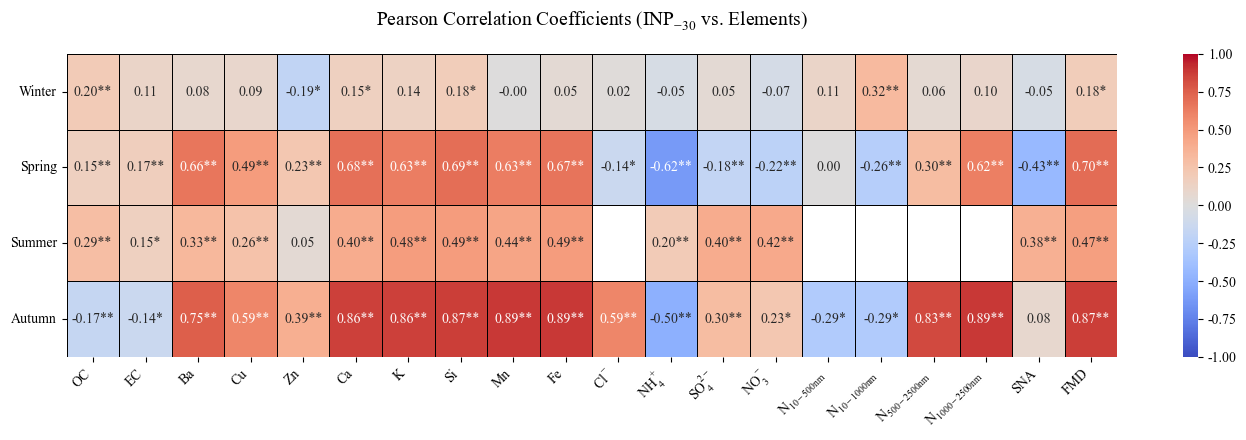

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# ==========================================
# 1. 设置全局字体为 Times New Roman
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman'

# ==========================================
# 2. 读取和预处理数据
# ==========================================
df = pd.read_csv(r'D:\Coding\Data\Lanzhou_chemical\Pearson_Correlation_Matrix.csv', index_col=0)

# 分离用于颜色的纯数值矩阵 和 用于显示的文本标签矩阵
annot_df = df.copy() # 用于显示 (包含星号)
num_df = df.replace(r'\*+', '', regex=True).astype(float) # 去除星号转换为浮点数用于映射颜色

# ==========================================
# 3. 格式化列名 (将离子符号转为 LaTeX 上下标形式)
# ==========================================
col_mapping = {
    'NH4+': r'NH$_4^+$',
    'SO42-': r'SO$_4^{2-}$',
    'NO3-': r'NO$_3^-$',
    'Cl-': r'Cl$^-$',
    'OC(optical)': 'OC',
    'EC(optical)': 'EC',
    'N_10-500nm': 'N$_{10-500nm}$',
    'N_10-1000nm': 'N$_{10-1000nm}$',
    'N_500-2500nm': 'N$_{500-2500nm}$',
    'N_1000-2500nm': 'N$_{1000-2500nm}$',
}
num_df.rename(columns=col_mapping, inplace=True)
annot_df.rename(columns=col_mapping, inplace=True)

# ==========================================
# 4. 绘制热力图
# ==========================================
plt.figure(figsize=(14, 4.5)) # 设置画布尺寸 (宽, 高)

# 使用 seaborn 画图
ax = sns.heatmap(
    num_df, 
    annot=annot_df,      # 填入带有星号的字符串
    fmt='',              # 格式化字符串设为空，原样显示 annot 的内容
    cmap='coolwarm',
    center=0,            # 色带以 0 为中心
    vmin=-1, vmax=1,
    linewidths=0.5,      # 单元格边框宽度
    linecolor='black',   # 单元格边框颜色
)

# 设置坐标轴标签的旋转角度
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 隐藏横纵坐标的标题名（如果不想要原来的 index/columns 名称）
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Pearson Correlation Coefficients (INP$_{-30}$ vs. Elements)', fontsize=14, pad=20)
plt.tight_layout()

plt.savefig(r'D:\Coding\master0_2025\Thesis\Pearson_Heatmap(INP_vs_elements).png', dpi=500, bbox_inches='tight')
plt.show()


结果已保存至: D:\Coding\Data\Lanzhou_chemical\Pearson_Correlation_Matrix.csv


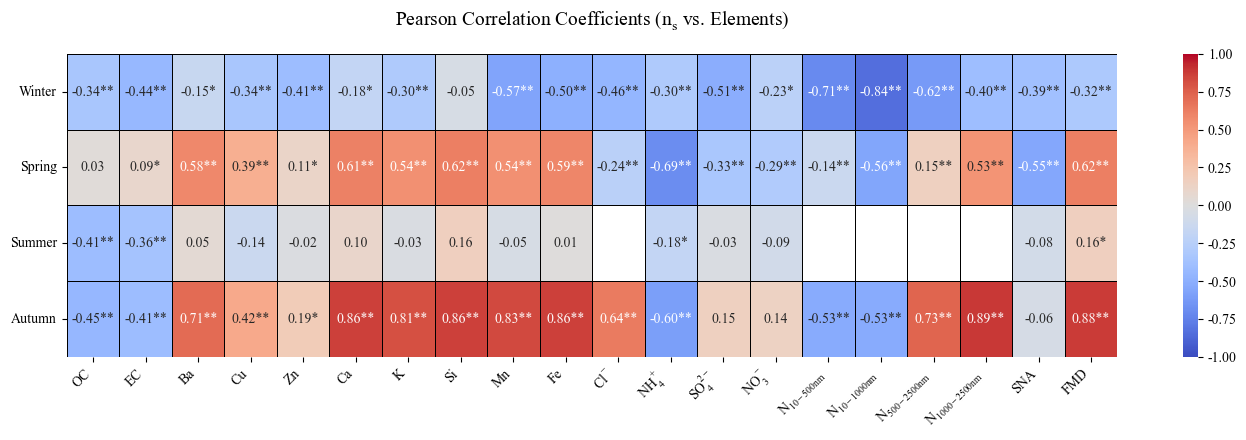

In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np

df_merged = pd.read_csv(r"D:\Coding\Data\Lanzhou_chemical\Corr_heatmap.csv")
df_merged['SNA'] = df_merged['NH4+'] + df_merged['SO42-'] + df_merged['NO3-']
df_merged['FMD'] = 2.20 * df_merged['Al'] + 2.49 * df_merged['Si'] + 1.63 * df_merged['Ca'] + 2.42 * df_merged['Fe'] + 1.94 * df_merged['Ti']

TARGET_TEMP = -30

ELEMENT_LIST = [
    "OC(optical)",
    "EC(optical)",
    "Ba",
    "Cu",
    "Zn",
    "Ca",
    "K",
    "Si",
    "Mn",
    "Fe",
    "Cl-",
    "NH4+",
    "SO42-",
    "NO3-",
    "N_10-500nm",
    "N_10-1000nm",
    "N_500-2500nm",
    "N_1000-2500nm",
    "SNA",
    "FMD",
]

INP_COL = "n_s"

LOG_TAG = 1


def calculate_corr_cell(df, temp, element, log_tag):
    """
    计算特定温度下，INP与特定物质的相关系数
    返回格式化的字符串 (例如: "0.38*" 或 "0.12")
    """
    # 1. 筛选特定温度的数据
    df_temp = df[df['T_a(degC)'] == temp]
    
    # 2. 去除空值 (Pairwise deletion)
    # 确保每列均为数值类型
    df_temp.loc[:, element] = pd.to_numeric(df_temp.loc[:, element], errors='coerce')
    df_temp.loc[:, INP_COL] = pd.to_numeric(df_temp.loc[:, INP_COL], errors='coerce')

    df_temp = df_temp.replace(-999, np.nan)
    df_sub = df_temp.dropna(subset=[element, INP_COL])

    # 3. 样本量检查 (如果样本太少，无法计算)
    if len(df_sub) < 3:
        return "nan"
    
    # 4. 提取数据
    x = df_sub[element]
    y = df_sub[INP_COL]
    
    # 5. 对数转换逻辑
    if log_tag:
        # 对数转换前必须确保数据 > 0
        valid_idx = (x > 0) & (y > 0)
        x = np.log10(x[valid_idx])
        y = np.log10(y[valid_idx])
        if len(x) < 3: return "nan"

    # 6. 计算 Pearson r 和 p
    # 如果数据方差为0（所有值都一样），返回nan
    if len(set(x)) == 1 or len(set(y)) == 1:
        return "nan"
    
    r, p = stats.pearsonr(x, y)

    # 7. 格式化输出
    if pd.isna(r):
        return "nan"
    
    # 标记显著性 (* 代表 p < 0.05)
    star = "*" if p < 0.05 else ""

    star = "**" if p < 0.01 else star
    
    return f"{r:.2f}{star}"
results = {}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    df_season = df_merged[df_merged['Season'] == season]

    row_name = f"{season}"
    row_data = {}
    
    for element in ELEMENT_LIST:
        # 检查元素列是否存在于数据中
        if element not in df_season.columns:
            row_data[element] = "No Data"
            continue
            
        # 调用函数计算
        res_str = calculate_corr_cell(df_season, TARGET_TEMP, element, LOG_TAG)
        row_data[element] = res_str
    
    results[row_name] = row_data

# 转换为 DataFrame (行是季节，列是物质名称)
df_result = pd.DataFrame(results).T 

# 保存为一个 CSV 文件, 每个季节一行
output_filename = r'D:\Coding\Data\Lanzhou_chemical\Pearson_Correlation_Matrix.csv'
df_result.to_csv(output_filename, index=True)
print(f"\n结果已保存至: {output_filename}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# ==========================================
# 1. 设置全局字体为 Times New Roman
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman'

# ==========================================
# 2. 读取和预处理数据
# ==========================================
df = pd.read_csv(r'D:\Coding\Data\Lanzhou_chemical\Pearson_Correlation_Matrix.csv', index_col=0)

# 分离用于颜色的纯数值矩阵 和 用于显示的文本标签矩阵
annot_df = df.copy() # 用于显示 (包含星号)
num_df = df.replace(r'\*+', '', regex=True).astype(float) # 去除星号转换为浮点数用于映射颜色

# ==========================================
# 3. 格式化列名 (将离子符号转为 LaTeX 上下标形式)
# ==========================================
col_mapping = {
    'NH4+': r'NH$_4^+$',
    'SO42-': r'SO$_4^{2-}$',
    'NO3-': r'NO$_3^-$',
    'Cl-': r'Cl$^-$',
    'OC(optical)': 'OC',
    'EC(optical)': 'EC',
    'N_10-500nm': 'N$_{10-500nm}$',
    'N_10-1000nm': 'N$_{10-1000nm}$',
    'N_500-2500nm': 'N$_{500-2500nm}$',
    'N_1000-2500nm': 'N$_{1000-2500nm}$',
    'n_s': 'n$_s$',
}
num_df.rename(columns=col_mapping, inplace=True)
annot_df.rename(columns=col_mapping, inplace=True)

# ==========================================
# 4. 绘制热力图
# ==========================================
plt.figure(figsize=(14, 4.5)) # 设置画布尺寸 (宽, 高)

# 使用 seaborn 画图
ax = sns.heatmap(
    num_df, 
    annot=annot_df,      # 填入带有星号的字符串
    fmt='',              # 格式化字符串设为空，原样显示 annot 的内容
    cmap='coolwarm',
    center=0,            # 色带以 0 为中心
    vmin=-1, vmax=1,
    linewidths=0.5,      # 单元格边框宽度
    linecolor='black',   # 单元格边框颜色
)

# 设置坐标轴标签的旋转角度
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 隐藏横纵坐标的标题名（如果不想要原来的 index/columns 名称）
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Pearson Correlation Coefficients (n$_s$ vs. Elements)', fontsize=14, pad=20)
plt.tight_layout()

plt.savefig(r'D:\Coding\master0_2025\Thesis\Pearson_Heatmap(INP_vs_elements).png', dpi=500, bbox_inches='tight')
plt.show()